In [14]:
import BigDataAnalysis_Package_RF as bda
import pandas as pd
import gc
import os
from joblib import Parallel, delayed

import importlib
importlib.reload(bda)


<module 'BigDataAnalysis_Package_RF' from 'd:\\Code\\Python\\BigDataAnalysis_Package_RF.py'>

In [ ]:
X_a_path = 'Data/Xa'
X_b_path = 'Data/Xb'
Y_a_path = 'Data/Ya'
Y_b_path = 'Data/Yb'

X_a = bda.read_data(X_a_path)
X_b = bda.read_data(X_b_path)
Y_a = bda.read_data(Y_a_path)
Y_b = bda.read_data(Y_b_path)

X_a = bda.tune_data(X_a, 15000)
X_b = bda.tune_data(X_b, 15000)
Y_a = bda.tune_data(Y_a, 15000)
Y_b = bda.tune_data(Y_b, 15000)

Data = {'Xa':X_a, 'Xb':X_b, 'Ya':Y_a, 'Yb':Y_b}

all_dict = {}
for _, d in Data.items():
    all_dict.update(d)

In [ ]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

centers_bands = {}
for group in ("Xa", "Xb", "Ya", "Yb"):
    centers_bands[group] = bda.build_centers_bands_for_group(all_dict, group, fmax=1250)

items = list(all_dict.items())
key_cols = ["Direction", "Load", "Index"]

base_chunk_size = 30  
base_chunks = list(bda.chunk_list(items, base_chunk_size))

base_rows_nested = Parallel(n_jobs=-1, backend="loky", batch_size=1, pre_dispatch="2*n_jobs")(delayed(bda._base_chunk)(ch) for ch in base_chunks)

base_rows = [r for chunk in base_rows_nested for r in chunk]
base_df = pd.DataFrame(base_rows)

base_df["GT_Health"] = base_df.apply(bda.assign_gt_health, axis=1)
base_df = base_df.set_index(key_cols, drop=False)

chunk_size = 10
chunks = list(bda.chunk_list(items, chunk_size))
abn_rows_nested = Parallel(n_jobs=-1, backend="loky", batch_size=1, pre_dispatch="2*n_jobs")(delayed(bda._abn_chunk)(ch, centers_bands) for ch in chunks)

abn_rows = [r for chunk in abn_rows_nested for r in chunk]

abn_df = pd.DataFrame(abn_rows)
abn_df = abn_df.set_index(key_cols, drop=False)

In [4]:
all_pack = {}
for g in ('Xa', 'Xb', 'Ya', 'Yb'):
    all_pack[g] = bda.build_cv_pack_for_group(base_df, abn_df, g, n_splits=5, seed=42)

In [10]:
results = []
for group, group_pack in all_pack.items():
    for fold_id, fold_pack in group_pack.items():
        y_true, y_pred, metrics = bda.run_pipeline_on_fold(
            fold_pack,
            group=group,
            seed=42
        )
        fn = metrics["cm"][1,0] 
        tn = metrics["cm"][0,0]
        npv = tn / (fn + tn + 1e-12)
        results.append({
            "Group": group,
            "Fold": fold_id,
            "y_true": y_true,
            "y_pred": y_pred,
            "acc": metrics["acc"],
            "auc": metrics["auc"],
            "cm": metrics["cm"],
            'npv': npv,
            'recall': metrics["recall"]
        })
        del y_true, y_pred, metrics, fold_pack
        gc.collect()
    del group_pack
    gc.collect()
results_df = pd.DataFrame(results)

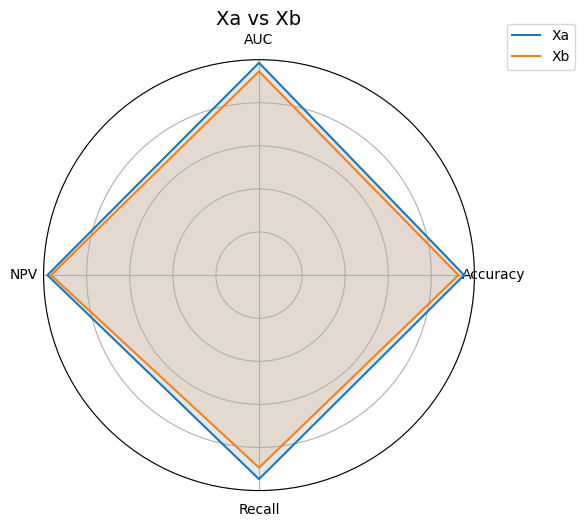

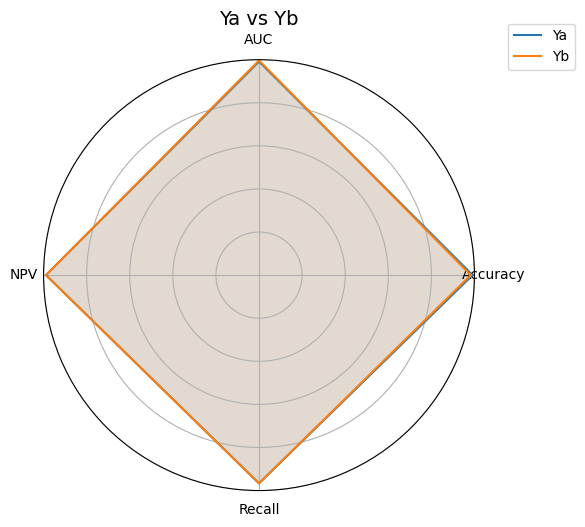

In [11]:
group_means = results_df.groupby("Group")[["acc", "auc", "npv", "recall"]].mean()
x_groups = [g for g in ["Xa", "Xb"] if g in group_means.index]
y_groups = [g for g in ["Ya", "Yb"] if g in group_means.index]

bda.plot_radar(x_groups, "Xa vs Xb", group_means)
bda.plot_radar(y_groups, "Ya vs Yb", group_means)

In [13]:
cols = ["acc", "auc", "npv", "recall", "cm"]
for g in ('Xa', 'Xb', 'Ya', 'Yb'):
    df = results_df[results_df["Group"] == g]
    metrics = df[cols]
    print(metrics)
    print(df[["acc", "auc", "npv", "recall"]].mean())

        acc       auc       npv    recall                  cm
0  0.956522  0.971429  1.000000  1.000000  [[33, 2], [0, 11]]
1  0.913043  0.989610  0.969697  0.909091  [[32, 3], [1, 10]]
2  0.956522  0.987013  1.000000  1.000000  [[33, 2], [0, 11]]
3  0.956522  0.980392  0.970588  0.916667  [[33, 1], [1, 11]]
4  0.977778  1.000000  0.971429  0.909091  [[34, 0], [1, 10]]
acc       0.952077
auc       0.985689
npv       0.982343
recall    0.946970
dtype: float64
        acc       auc       npv    recall                  cm
5  0.913043  0.945455  0.942857  0.818182   [[33, 2], [2, 9]]
6  0.869565  0.955844  1.000000  1.000000  [[29, 6], [0, 11]]
7  0.978261  0.946753  0.972222  0.909091  [[35, 0], [1, 10]]
8  0.956522  0.950980  0.944444  0.833333  [[34, 0], [2, 10]]
9  0.911111  0.929144  0.968750  0.909091  [[31, 3], [1, 10]]
acc       0.925700
auc       0.945635
npv       0.965655
recall    0.893939
dtype: float64
         acc       auc       npv    recall                  cm
10  1.00000